<a href="https://colab.research.google.com/github/ZIZOUTOUMOU/LAB02-AdvDB/blob/main/fire_alarm_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)

sns.set_style("whitegrid")
RANDOM_STATE = 42

In [2]:
csv_path = None

# 1) Kaggle: look for an attached dataset
if os.path.exists("/kaggle/input"):
    for dirname, _, filenames in os.walk("/kaggle/input"):
        for f in filenames:
            if f.endswith(".csv"):
                csv_path = os.path.join(dirname, f)

# 2) Fallback (Colab / local): download with kagglehub
if csv_path is None:
    !pip install -q kagglehub
    import kagglehub
    folder = kagglehub.dataset_download("deepcontractor/smoke-detection-dataset")
    for dirname, _, filenames in os.walk(folder):
        for f in filenames:
            if f.endswith(".csv"):
                csv_path = os.path.join(dirname, f)

assert csv_path is not None, "No CSV found. On Kaggle, use + Add Input to attach the Smoke Detection Dataset."
print("Using:", csv_path)

df = pd.read_csv(csv_path)

# XGBoost does not accept [, ] or < in feature names (e.g. 'Temperature[C]'),
# so we clean the column names once here and every model uses the same names.
df.columns = [re.sub(r"[\[\]<]", "", c).strip() for c in df.columns]

print("\nShape:", df.shape)
print("Columns:", list(df.columns))
df.head()

Using Colab cache for faster access to the 'smoke-detection-dataset' dataset.
Using: /kaggle/input/smoke-detection-dataset/smoke_detection_iot.csv

Shape: (62630, 16)
Columns: ['Unnamed: 0', 'UTC', 'TemperatureC', 'Humidity%', 'TVOCppb', 'eCO2ppm', 'Raw H2', 'Raw Ethanol', 'PressurehPa', 'PM1.0', 'PM2.5', 'NC0.5', 'NC1.0', 'NC2.5', 'CNT', 'Fire Alarm']


,Unnamed: 0,UTC,TemperatureC,Humidity%,TVOCppb,eCO2ppm,Raw H2,Raw Ethanol,PressurehPa,PM1.0,PM2.5,NC0.5,NC1.0,NC2.5,CNT,Fire Alarm
0,0,1654733331,20.000,57.36,0,400,12306,18520,939.735,0.0,0.0,0.0,0.0,0.0,0,0
1,1,1654733332,20.015,56.67,0,400,12345,18651,939.744,0.0,0.0,0.0,0.0,0.0,1,0
2,2,1654733333,20.029,55.96,0,400,12374,18764,939.738,0.0,0.0,0.0,0.0,0.0,2,0
3,3,1654733334,20.044,55.28,0,400,12390,18849,939.736,0.0,0.0,0.0,0.0,0.0,3,0
4,4,1654733335,20.059,54.69,0,400,12403,18921,939.744,0.0,0.0,0.0,0.0,0.0,4,0


In [3]:
# Structure, dtypes and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62630 entries, 0 to 62629
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    62630 non-null  int64  
 1   UTC           62630 non-null  int64  
 2   TemperatureC  62630 non-null  float64
 3   Humidity%     62630 non-null  float64
 4   TVOCppb       62630 non-null  int64  
 5   eCO2ppm       62630 non-null  int64  
 6   Raw H2        62630 non-null  int64  
 7   Raw Ethanol   62630 non-null  int64  
 8   PressurehPa   62630 non-null  float64
 9   PM1.0         62630 non-null  float64
 10  PM2.5         62630 non-null  float64
 11  NC0.5         62630 non-null  float64
 12  NC1.0         62630 non-null  float64
 13  NC2.5         62630 non-null  float64
 14  CNT           62630 non-null  int64  
 15  Fire Alarm    62630 non-null  int64  
dtypes: float64(8), int64(8)
memory usage: 7.6 MB


In [4]:
# Missing values per column
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Unnamed: 0      0
UTC             0
TemperatureC    0
Humidity%       0
TVOCppb         0
eCO2ppm         0
Raw H2          0
Raw Ethanol     0
PressurehPa     0
PM1.0           0
PM2.5           0
NC0.5           0
NC1.0           0
NC2.5           0
CNT             0
Fire Alarm      0
dtype: int64

Duplicate rows: 0


In [5]:
# Handle missing data: removal (if any rows have NaNs) – imputation would be an alternative
before = len(df)
df = df.dropna().reset_index(drop=True)
print(f"Rows removed due to missing values: {before - len(df)}")

Rows removed due to missing values: 0


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,62630.0,3.131450e+04,18079.868017,0.000000e+00,1.565725e+04,3.131450e+04,4.697175e+04,6.262900e+04
UTC,62630.0,1.654792e+09,110002.488078,1.654712e+09,1.654743e+09,1.654762e+09,1.654778e+09,1.655130e+09
TemperatureC,62630.0,1.597042e+01,14.359576,-2.201000e+01,1.099425e+01,2.013000e+01,2.540950e+01,5.993000e+01
Humidity%,62630.0,4.853950e+01,8.865367,1.074000e+01,4.753000e+01,5.015000e+01,5.324000e+01,7.520000e+01
TVOCppb,62630.0,1.942058e+03,7811.589055,0.000000e+00,1.300000e+02,9.810000e+02,1.189000e+03,6.000000e+04
eCO2ppm,62630.0,6.700210e+02,1905.885439,4.000000e+02,4.000000e+02,4.000000e+02,4.380000e+02,6.000000e+04
Raw H2,62630.0,1.294245e+04,272.464305,1.066800e+04,1.283000e+04,1.292400e+04,1.310900e+04,1.380300e+04
Raw Ethanol,62630.0,1.975426e+04,609.513156,1.531700e+04,1.943500e+04,1.950100e+04,2.007800e+04,2.141000e+04
PressurehPa,62630.0,9.386276e+02,1.331344,9.308520e+02,9.387000e+02,9.388160e+02,9.394180e+02,9.398610e+02
PM1.0,62630.0,1.005943e+02,922.524245,0.000000e+00,1.280000e+00,1.810000e+00,2.090000e+00,1.433369e+04


Fire Alarm
1    44757
0    17873
Name: count, dtype: int64
Fire Alarm
1    71.46 %
0    28.54 %
Name: count, dtype: object


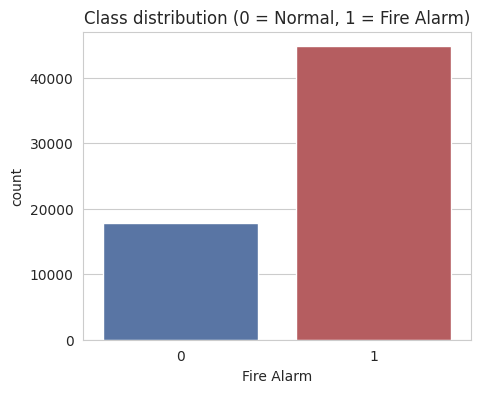

In [7]:
# Class balance of the target
target_col = "Fire Alarm"
counts = df[target_col].value_counts()
print(counts)
print((counts / len(df) * 100).round(2).astype(str) + " %")

plt.figure(figsize=(5, 4))
sns.countplot(x=target_col, data=df, palette=["#4C72B0", "#C44E52"])
plt.title("Class distribution (0 = Normal, 1 = Fire Alarm)")
plt.show()

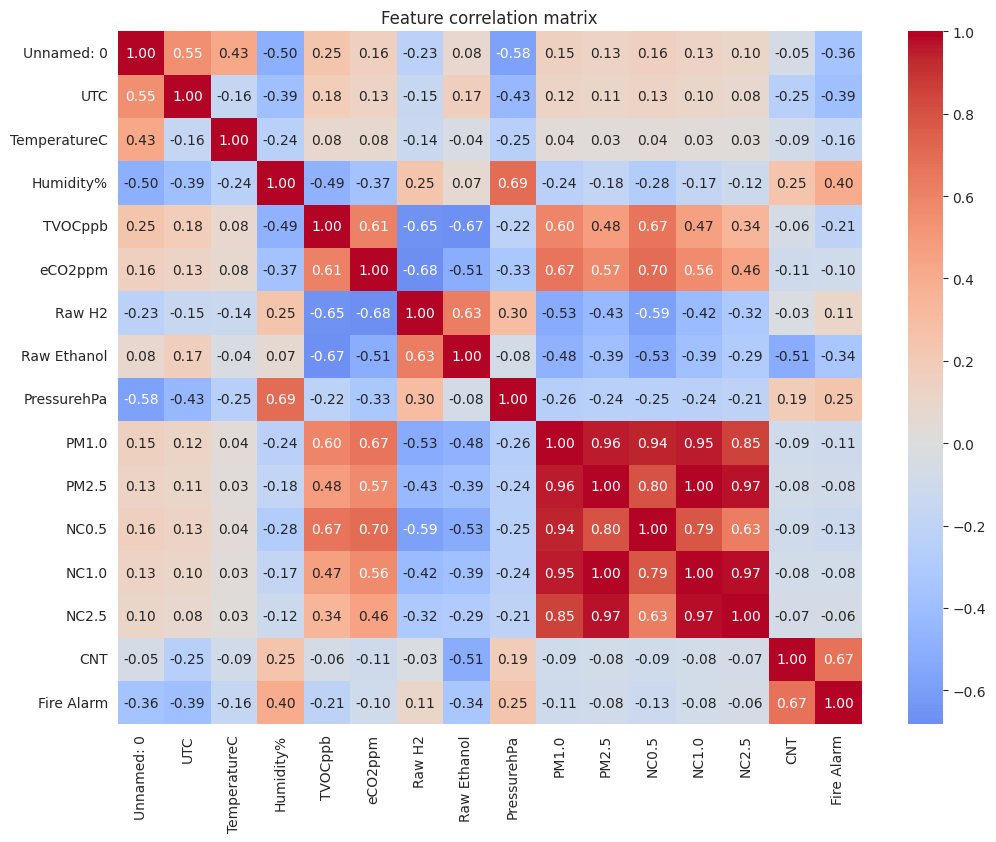

In [8]:
# Correlation heatmap
plt.figure(figsize=(12, 9))
num_df = df.select_dtypes(include=np.number)
sns.heatmap(num_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature correlation matrix")
plt.show()

In [9]:
drop_cols = [c for c in ["Unnamed: 0", "UTC", "CNT"] if c in df.columns]
X = df.drop(columns=drop_cols + [target_col])
y = df[target_col]

print("Features used:", list(X.columns))
print("X shape:", X.shape, "| y shape:", y.shape)

Features used: ['TemperatureC', 'Humidity%', 'TVOCppb', 'eCO2ppm', 'Raw H2', 'Raw Ethanol', 'PressurehPa', 'PM1.0', 'PM2.5', 'NC0.5', 'NC1.0', 'NC2.5']
X shape: (62630, 12) | y shape: (62630,)


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print("Train:", X_train.shape, "| Test:", X_test.shape)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # learn mean/std from train only
X_test_scaled  = scaler.transform(X_test)        # apply the same transformation

pd.DataFrame(X_train_scaled, columns=X.columns).describe().loc[["mean", "std"]].round(3)

Train: (50104, 12) | Test: (12526, 12)


,TemperatureC,Humidity%,TVOCppb,eCO2ppm,Raw H2,Raw Ethanol,PressurehPa,PM1.0,PM2.5,NC0.5,NC1.0,NC2.5
mean,0.0,0.0,-0.0,-0.0,0.0,-0.0,0.0,0.0,-0.0,0.0,0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [11]:
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)
print("Logistic Regression trained.")

Logistic Regression trained.


In [12]:
y_pred_lr = log_reg.predict(X_test_scaled)
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

In [13]:
def evaluate(name, y_true, y_pred):
    res = {
        "Model": name,
        "Accuracy":  accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall":    recall_score(y_true, y_pred),
        "F1-Score":  f1_score(y_true, y_pred),
    }
    return res

lr_results = evaluate("Logistic Regression", y_test, y_pred_lr)
for k, v in lr_results.items():
    print(f"{k:10s}: {v:.4f}" if k != "Model" else f"{k}: {v}")

print("\nFull classification report:\n")
print(classification_report(y_test, y_pred_lr, target_names=["Normal (0)", "Fire Alarm (1)"]))

Model: Logistic Regression
Accuracy  : 0.8951
Precision : 0.9090
Recall    : 0.9482
F1-Score  : 0.9281

Full classification report:

                precision    recall  f1-score   support

    Normal (0)       0.85      0.76      0.81      3575
Fire Alarm (1)       0.91      0.95      0.93      8951

      accuracy                           0.90     12526
     macro avg       0.88      0.86      0.87     12526
  weighted avg       0.89      0.90      0.89     12526



### 4.4 Confusion matrix

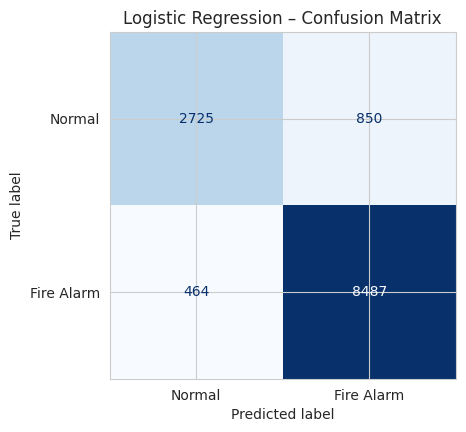

True Negatives : 2725
False Positives: 850  (false alarms)
False Negatives: 464  (MISSED fires – most dangerous)
True Positives : 8487


In [14]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
tn, fp, fn, tp = cm_lr.ravel()

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay(cm_lr, display_labels=["Normal", "Fire Alarm"]).plot(
    ax=ax, cmap="Blues", values_format="d", colorbar=False)
ax.set_title("Logistic Regression – Confusion Matrix")
plt.show()

print(f"True Negatives : {tn}")
print(f"False Positives: {fp}  (false alarms)")
print(f"False Negatives: {fn}  (MISSED fires – most dangerous)")
print(f"True Positives : {tp}")

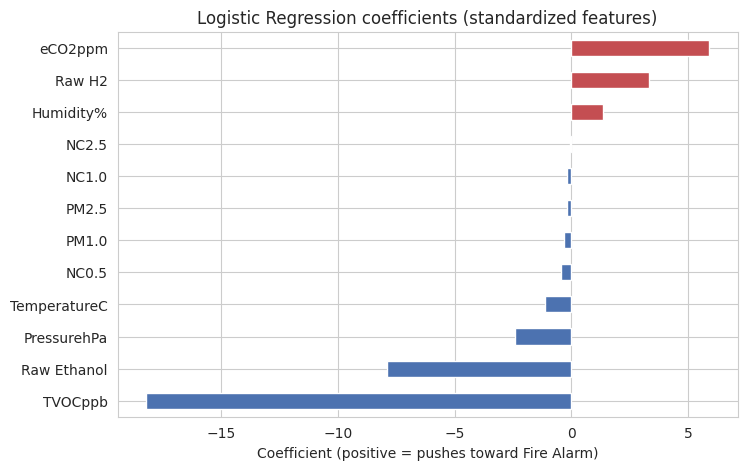

In [15]:
# Which sensors matter most? (coefficients on standardized features are directly comparable)
coef = pd.Series(log_reg.coef_[0], index=X.columns).sort_values()
plt.figure(figsize=(8, 5))
coef.plot(kind="barh", color=np.where(coef > 0, "#C44E52", "#4C72B0"))
plt.title("Logistic Regression coefficients (standardized features)")
plt.xlabel("Coefficient (positive = pushes toward Fire Alarm)")
plt.show()

## 5. Conclusion – Logistic Regression

In [16]:
lr_recall = lr_results["Recall"]
print(f"Logistic Regression Recall = {lr_recall:.4f}")
print(f"Out of {tp + fn} real fire/alarm samples in the test set, "
      f"{tp} were detected and {fn} were missed.")
print(f"Out of {tn + fp} normal samples, {fp} triggered a false alarm.")

Logistic Regression Recall = 0.9482
Out of 8951 real fire/alarm samples in the test set, 8487 were detected and 464 were missed.
Out of 3575 normal samples, 850 triggered a false alarm.


In [17]:
try:
    from xgboost import XGBClassifier
except ImportError:
    !pip install -q xgboost
    from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]
print("XGBoost trained.")

XGBoost trained.


In [18]:
xgb_results = evaluate("XGBoost", y_test, y_pred_xgb)
for k, v in xgb_results.items():
    print(f"{k:10s}: {v:.4f}" if k != "Model" else f"{k}: {v}")

print("\nFull classification report:\n")
print(classification_report(y_test, y_pred_xgb, target_names=["Normal (0)", "Fire Alarm (1)"]))

Model: XGBoost
Accuracy  : 0.9999
Precision : 1.0000
Recall    : 0.9999
F1-Score  : 0.9999

Full classification report:

                precision    recall  f1-score   support

    Normal (0)       1.00      1.00      1.00      3575
Fire Alarm (1)       1.00      1.00      1.00      8951

      accuracy                           1.00     12526
     macro avg       1.00      1.00      1.00     12526
  weighted avg       1.00      1.00      1.00     12526



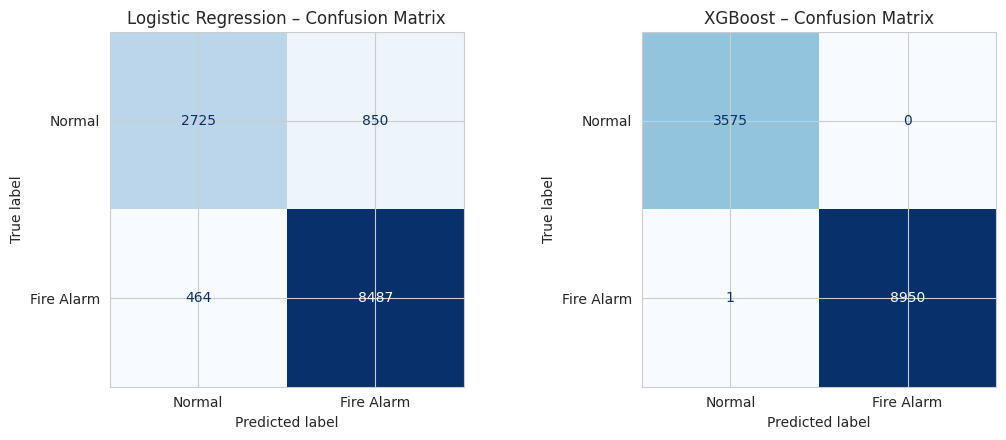

XGBoost  -> False Negatives: 1 | False Positives: 0
LogReg   -> False Negatives: 464   | False Positives: 850


In [19]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
tn_x, fp_x, fn_x, tp_x = cm_xgb.ravel()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, cm, title in zip(axes, [cm_lr, cm_xgb], ["Logistic Regression", "XGBoost"]):
    ConfusionMatrixDisplay(cm, display_labels=["Normal", "Fire Alarm"]).plot(
        ax=ax, cmap="Blues", values_format="d", colorbar=False)
    ax.set_title(f"{title} – Confusion Matrix")
plt.tight_layout()
plt.show()

print(f"XGBoost  -> False Negatives: {fn_x} | False Positives: {fp_x}")
print(f"LogReg   -> False Negatives: {fn}   | False Positives: {fp}")

,Accuracy,Precision,Recall,F1-Score
Model,,,,
Logistic Regression,0.8951,0.909,0.9482,0.9281
XGBoost,0.9999,1.000,0.9999,0.9999


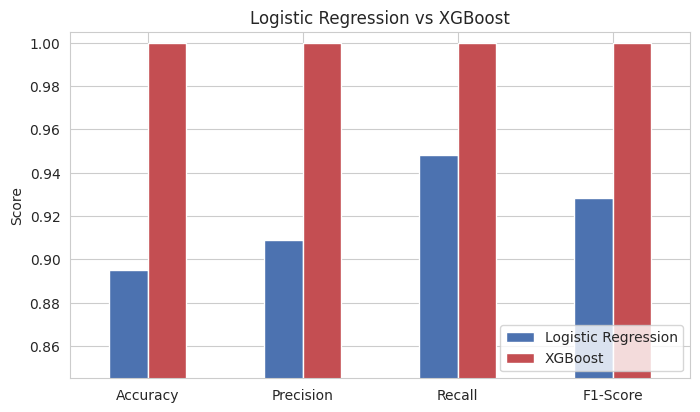

In [20]:
# Side-by-side comparison
comparison = pd.DataFrame([lr_results, xgb_results]).set_index("Model")
display(comparison.round(4))

comparison.T.plot(kind="bar", figsize=(8, 4.5), rot=0, color=["#4C72B0", "#C44E52"])
plt.ylim(max(0, comparison.values.min() - 0.05), 1.005)
plt.title("Logistic Regression vs XGBoost")
plt.ylabel("Score")
plt.legend(loc="lower right")
plt.show()

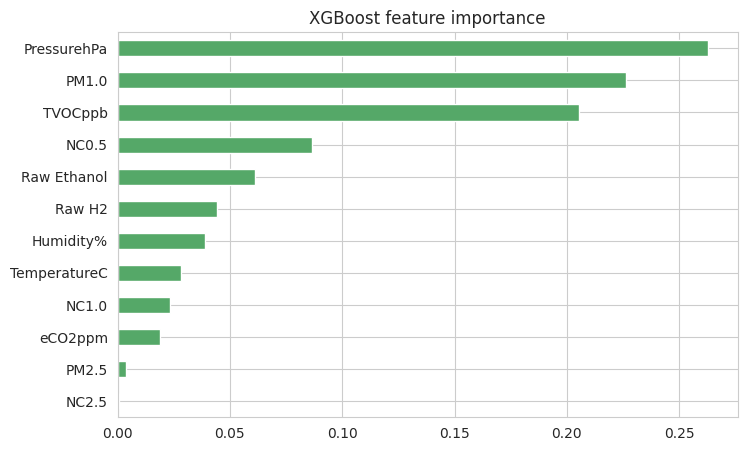

In [21]:
# XGBoost feature importance
imp = pd.Series(xgb.feature_importances_, index=X.columns).sort_values()
plt.figure(figsize=(8, 5))
imp.plot(kind="barh", color="#55A868")
plt.title("XGBoost feature importance")
plt.show()

In [22]:
# Practical trade-off: inference cost
import time
def time_model(predict_fn, X_in, repeats=20):
    t0 = time.perf_counter()
    for _ in range(repeats):
        predict_fn(X_in)
    return (time.perf_counter() - t0) / repeats / len(X_in) * 1e6   # microseconds / sample

print(f"Logistic Regression: {time_model(log_reg.predict, X_test_scaled):.2f} µs / sample")
print(f"XGBoost            : {time_model(xgb.predict, X_test):.2f} µs / sample")

Logistic Regression: 0.12 µs / sample
XGBoost            : 11.65 µs / sample


In [23]:
# Automatic answer to: "Which model has a higher Recall?"
r_lr, r_xgb = lr_results["Recall"], xgb_results["Recall"]
if r_xgb > r_lr:
    winner = "XGBoost"
elif r_lr > r_xgb:
    winner = "Logistic Regression"
else:
    winner = "Both models (tie)"
print(f"Recall  LogReg = {r_lr:.4f} | XGBoost = {r_xgb:.4f}")
print(f"Higher Recall: {winner}")
print(f"Missed fires (FN): LogReg = {fn} | XGBoost = {fn_x}")

Recall  LogReg = 0.9482 | XGBoost = 0.9999
Higher Recall: XGBoost
Missed fires (FN): LogReg = 464 | XGBoost = 1
